In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv("../data/train.csv")

if "id" in df.columns:
    df = df.drop(columns=["id"])

df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [53]:
# start feature engineering
df["soil_lt_25"] = (df["Soil_Moisture"] < 25).astype(int)
df["rain_lt_300"] = (df["Rainfall_mm"] < 300).astype(int)
df["temp_gt_30"] = (df["Temperature_C"] > 30).astype(int)

df["magic_score"] = (
    df["soil_lt_25"] +
    df["rain_lt_300"] +
    df["temp_gt_30"]
)

# new features
df["temp_x_humidity"] = df["Temperature_C"] * df["Humidity"]
df["moisture_per_rain"] = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)

In [54]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'soil_lt_25', 'rain_lt_300', 'temp_gt_30', 'magic_score',
       'temp_x_humidity', 'moisture_per_rain'],
      dtype='str')

In [55]:
# Separate first
X = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]

# then encode the features
X = pd.get_dummies(X, drop_first=True)

# then encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [56]:
# use train test split so we can evaluate and fix before submitting

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model 1: xgboost

In [57]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

XGBoost Accuracy: 0.9859365079365079


model 2: lightgbm

In [58]:
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb.fit(X_train, y_train)

lgb_preds = lgb.predict(X_test)
lgb_probs = lgb.predict_proba(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, lgb_preds))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 41
[LightGBM] [Info] Start training from score -3.400781
[LightGBM] [Info] Start training from score -0.532440
[LightGBM] [Info] Start training from score -0.968948
LightGBM Accuracy: 0.9856190476190476


model 3: LogReg

In [59]:
lr = LogisticRegression(max_iter=3000, random_state=42)

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.9336428571428571


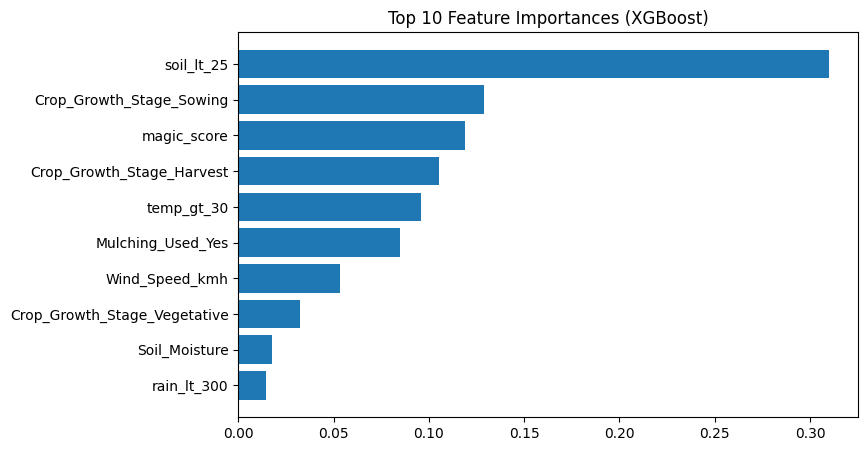

In [60]:
importances = xgb.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

In [61]:
ensemble_probs = (
    0.5 * xgb_probs +
    0.5 * lgb_probs
)

ensemble_preds = np.argmax(ensemble_probs, axis=1)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_preds))

Ensemble Accuracy: 0.9858888888888889


In [62]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "Logistic Regression", "Ensemble"],
    "Accuracy": [
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, lgb_preds),
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, ensemble_preds)
    ]
})

results

,Model,Accuracy
0,XGBoost,0.985937
1,LightGBM,0.985619
2,Logistic Regression,0.933643
3,Ensemble,0.985889


In [63]:
test = pd.read_csv("../data/test.csv")
test_ids = test["id"]

In [64]:
# Drop id
test = test.drop(columns=["id"])

# Feature engineering (same as train)
test["soil_lt_25"] = (test["Soil_Moisture"] < 25).astype(int)
test["rain_lt_300"] = (test["Rainfall_mm"] < 300).astype(int)
test["temp_gt_30"] = (test["Temperature_C"] > 30).astype(int)

test["magic_score"] = (
    test["soil_lt_25"] +
    test["rain_lt_300"] +
    test["temp_gt_30"]
)

test["temp_x_humidity"] = test["Temperature_C"] * test["Humidity"]
test["moisture_per_rain"] = test["Soil_Moisture"] / (test["Rainfall_mm"] + 1)

In [65]:
test = pd.get_dummies(test, drop_first=True)
test = test.reindex(columns=X.columns, fill_value=0)

In [66]:
xgb.fit(X, y)
lgb.fit(X, y)
lr.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3237
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 41
[LightGBM] [Info] Start training from score -3.400769
[LightGBM] [Info] Start training from score -0.532441
[LightGBM] [Info] Start training from score -0.968947


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [67]:
xgb_preds_test = xgb.predict(test)
xgb_preds_test = le.inverse_transform(xgb_preds_test)

submission_xgb = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": xgb_preds_test
})

submission_xgb.to_csv("submission_xgb.csv", index=False)

In [68]:
lgb_preds_test = lgb.predict(test)
lgb_preds_test = le.inverse_transform(lgb_preds_test)

submission_lgb = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": lgb_preds_test
})

submission_lgb.to_csv("submission_lgb.csv", index=False)

In [69]:
lr_preds_test = lr.predict(test)
lr_preds_test = le.inverse_transform(lr_preds_test)

submission_lr = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": lr_preds_test
})

submission_lr.to_csv("submission_lr.csv", index=False)

In [70]:
xgb_probs_test = xgb.predict_proba(test)
lgb_probs_test = lgb.predict_proba(test)

ensemble_probs_test = 0.5 * xgb_probs_test + 0.5 * lgb_probs_test

ensemble_preds_test = np.argmax(ensemble_probs_test, axis=1)

In [71]:
final_preds = le.inverse_transform(ensemble_preds_test)
final_preds

array(['Low', 'Low', 'Low', ..., 'Medium', 'Low', 'Medium'],
      shape=(270000,), dtype=object)

In [72]:
submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": final_preds
})

submission.to_csv("submission_ensemble.csv", index=False)